# Hartmann 6D: fixed and rotating surrogate RF depths

Comparison of seven fixed RF depths, SMAC's default RF, and the rotating policy `3 → 8 → 12 → default`. Every setting has five seeds and 500 trials.

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "master_utils").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from master_utils.reload_components import load_smac_components

EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "hartmann" / "03_fixed_depths"
RUN_DIRECTORIES = {
    "Default": EXPERIMENT_DIR / "hartmann_6d_fixed_depths" / "default",
    "Depth 2": EXPERIMENT_DIR / "hartmann_6d_fixed_depths" / "depth_2",
    "Depth 4": EXPERIMENT_DIR / "hartmann_6d_fixed_depths" / "depth_4",
    "Depth 7": EXPERIMENT_DIR / "hartmann_6d_fixed_depths" / "depth_7",
    "Depth 10": EXPERIMENT_DIR / "hartmann_6d_fixed_depths" / "depth_10",
    "Depth 15": EXPERIMENT_DIR / "hartmann_6d_fixed_depths" / "depth_15",
    "Depth 20": EXPERIMENT_DIR / "hartmann_6d_fixed_depths" / "depth_20",
    "Depth 25": EXPERIMENT_DIR / "hartmann_6d_fixed_depths" / "depth_25",
    "Rotating 3/8/12/default": (
        EXPERIMENT_DIR
        / "hartmann_6d_rotating_depths"
        / "rotating_3_8_12_default"
    ),
}
SEEDS = range(5)
N_TRIALS = 500
HARTMANN_6D_MINIMUM = -3.322368011415515
CONFIDENCE = 0.95
ROTATING_LABEL = "Rotating 3/8/12/default"

plt.rcParams.update({"figure.figsize": (11, 6.5), "axes.grid": True})

## Load all 45 SMAC runs

In [9]:
runs = {
    label: {
        seed: load_smac_components(directory / str(seed))
        for seed in SEEDS
    }
    for label, directory in RUN_DIRECTORIES.items()
}


def incumbent_trajectory(runhistory):
    trials = sorted(runhistory.items(), key=lambda item: item[1].starttime)
    costs = np.asarray([value.cost for _, value in trials], dtype=float)
    return np.minimum.accumulate(costs)


incumbent_costs = {}
for label, setting_runs in runs.items():
    trajectories = [
        incumbent_trajectory(setting_runs[seed]["runhistory"])
        for seed in SEEDS
    ]
    lengths = [len(trajectory) for trajectory in trajectories]
    assert min(lengths) >= N_TRIALS, f"{label}: {lengths}"
    incumbent_costs[label] = np.vstack(
        [trajectory[:N_TRIALS] for trajectory in trajectories]
    )

trial_numbers = np.arange(1, N_TRIALS + 1)
{label: values.shape for label, values in incumbent_costs.items()}

{'Default': (5, 500),
 'Depth 2': (5, 500),
 'Depth 4': (5, 500),
 'Depth 7': (5, 500),
 'Depth 10': (5, 500),
 'Depth 15': (5, 500),
 'Depth 20': (5, 500),
 'Depth 25': (5, 500),
 'Rotating 3/8/12/default': (5, 500)}

In [10]:
def mean_and_ci(values, confidence=CONFIDENCE):
    values = np.asarray(values, dtype=float)
    mean = values.mean(axis=0)
    sem = values.std(axis=0, ddof=1) / np.sqrt(values.shape[0])
    critical_value = t.ppf((1 + confidence) / 2, df=values.shape[0] - 1)
    half_width = critical_value * sem
    return mean, mean - half_width, mean + half_width


labels = list(RUN_DIRECTORIES)
colors = dict(zip(labels, plt.get_cmap("tab10").colors))


def line_style(label):
    if label == ROTATING_LABEL:
        return {"linestyle": "--", "linewidth": 2.8}
    return {"linestyle": "-", "linewidth": 1.5}


def add_external_legend(ax):
    ax.legend(title="RF setting", loc="center left", bbox_to_anchor=(1.02, 0.5))

## 1. Final incumbent performance

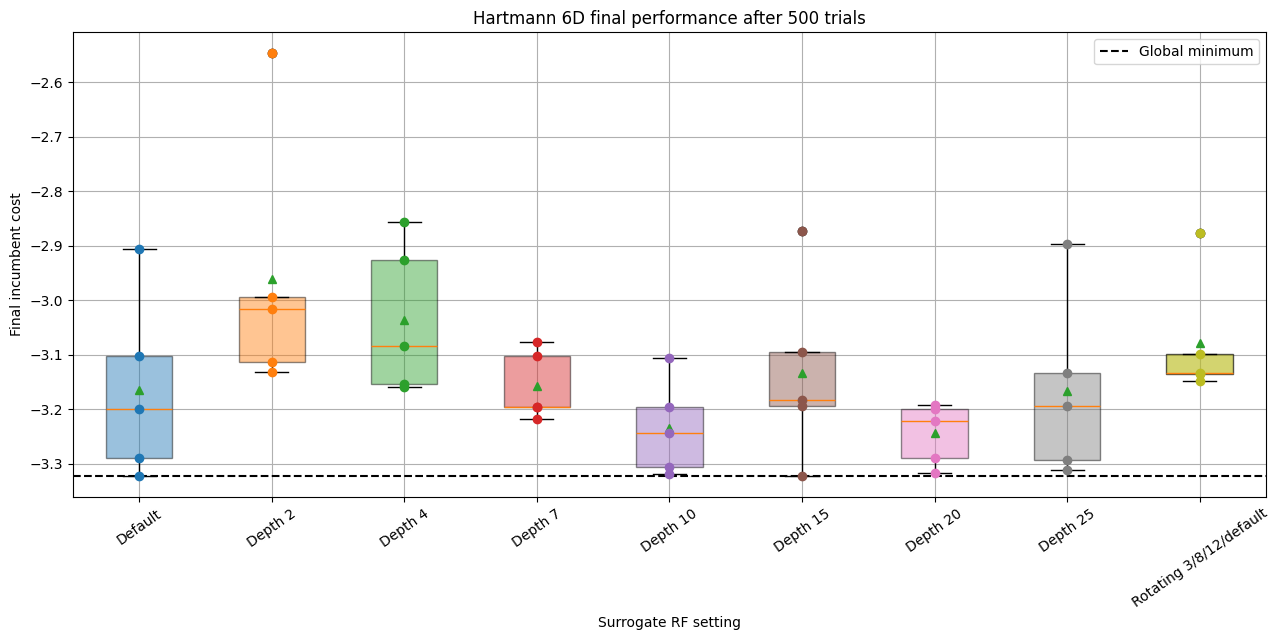

In [11]:
final_costs = [incumbent_costs[label][:, -1] for label in labels]

fig, ax = plt.subplots(figsize=(13, 6.5))
boxplot = ax.boxplot(final_costs, tick_labels=labels, showmeans=True, patch_artist=True)
for patch, label in zip(boxplot["boxes"], labels):
    patch.set_facecolor(colors[label])
    patch.set_alpha(0.65 if label == ROTATING_LABEL else 0.45)
for position, values in enumerate(final_costs, start=1):
    ax.scatter(np.full(len(values), position), values, color=colors[labels[position - 1]], zorder=3)
ax.axhline(HARTMANN_6D_MINIMUM, color="black", linestyle="--", label="Global minimum")
ax.set_xlabel("Surrogate RF setting")
ax.set_ylabel("Final incumbent cost")
ax.set_title("Hartmann 6D final performance after 500 trials")
ax.tick_params(axis="x", rotation=35)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Mean simple regret with 95% confidence intervals

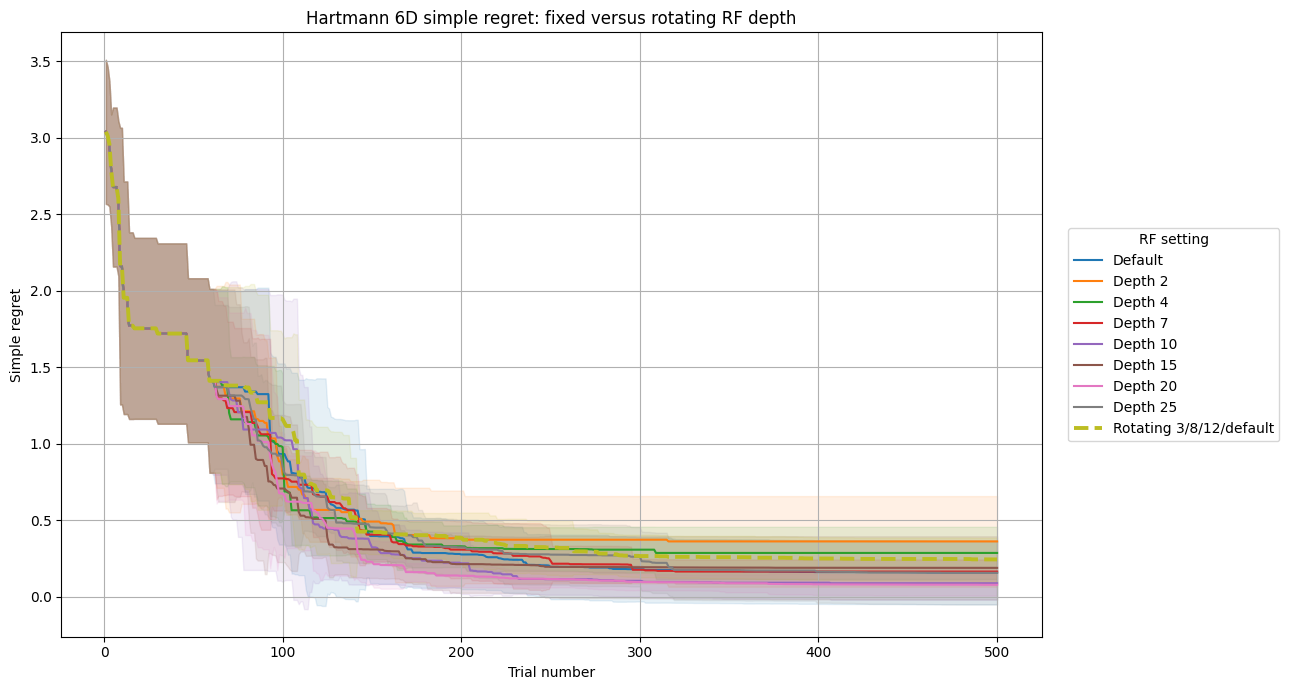

In [12]:
simple_regrets = {
    label: values - HARTMANN_6D_MINIMUM
    for label, values in incumbent_costs.items()
}

fig, ax = plt.subplots(figsize=(13, 7))
for label, regrets in simple_regrets.items():
    mean, lower, upper = mean_and_ci(regrets)
    ax.plot(trial_numbers, mean, color=colors[label], label=label, **line_style(label))
    ax.fill_between(trial_numbers, lower, upper, color=colors[label], alpha=0.11)
ax.set_xlabel("Trial number")
ax.set_ylabel("Simple regret")
ax.set_title("Hartmann 6D simple regret: fixed versus rotating RF depth")
add_external_legend(ax)
plt.tight_layout()
plt.show()

## 3. Mean log-simple-regret with 95% confidence intervals

The logarithm is applied before calculating the mean and Student's $t$ confidence interval.

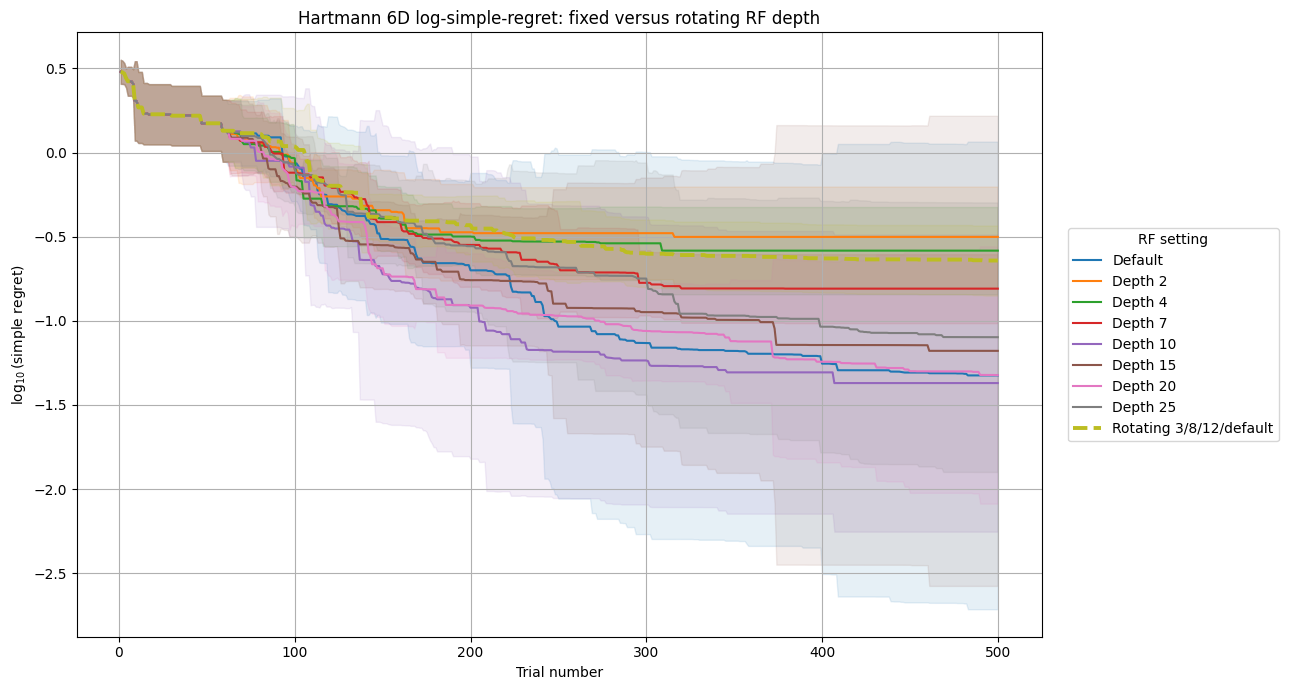

In [13]:
log10_simple_regrets = {
    label: np.log10(regrets)
    for label, regrets in simple_regrets.items()
}

fig, ax = plt.subplots(figsize=(13, 7))
for label, log_regrets in log10_simple_regrets.items():
    mean, lower, upper = mean_and_ci(log_regrets)
    ax.plot(trial_numbers, mean, color=colors[label], label=label, **line_style(label))
    ax.fill_between(trial_numbers, lower, upper, color=colors[label], alpha=0.11)
ax.set_xlabel("Trial number")
ax.set_ylabel(r"$\log_{10}$(simple regret)")
ax.set_title("Hartmann 6D log-simple-regret: fixed versus rotating RF depth")
add_external_legend(ax)
plt.tight_layout()
plt.show()

## 4. Incumbent performance at 100, 200, 300, 400, and 500 trials

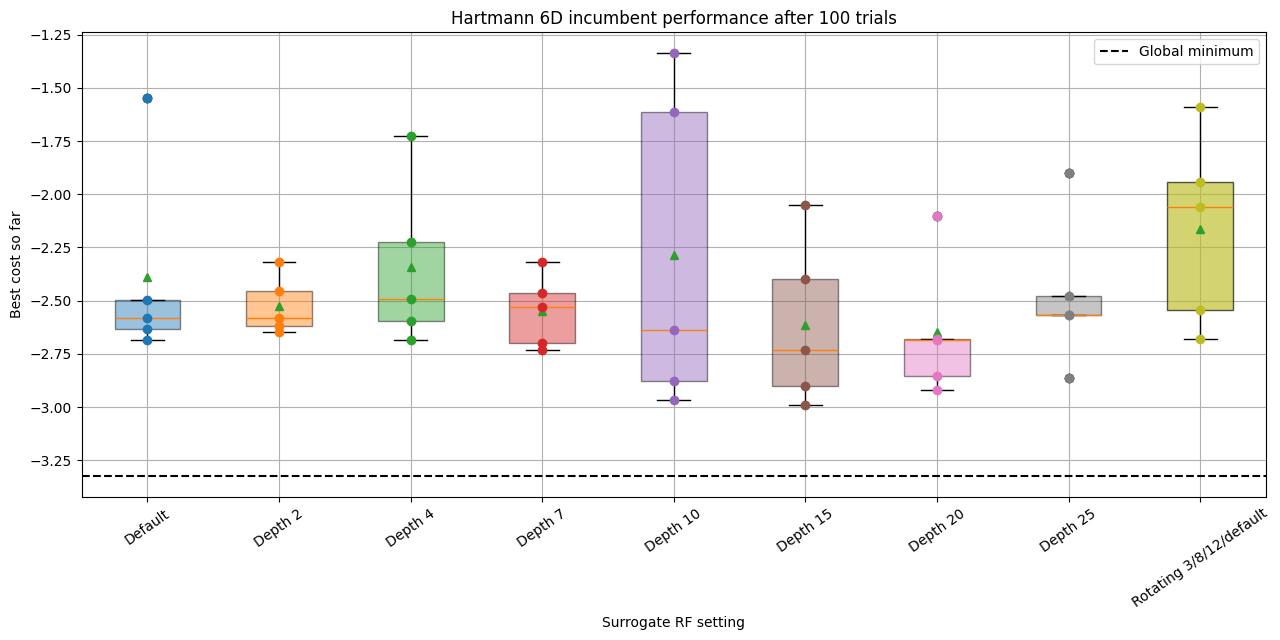

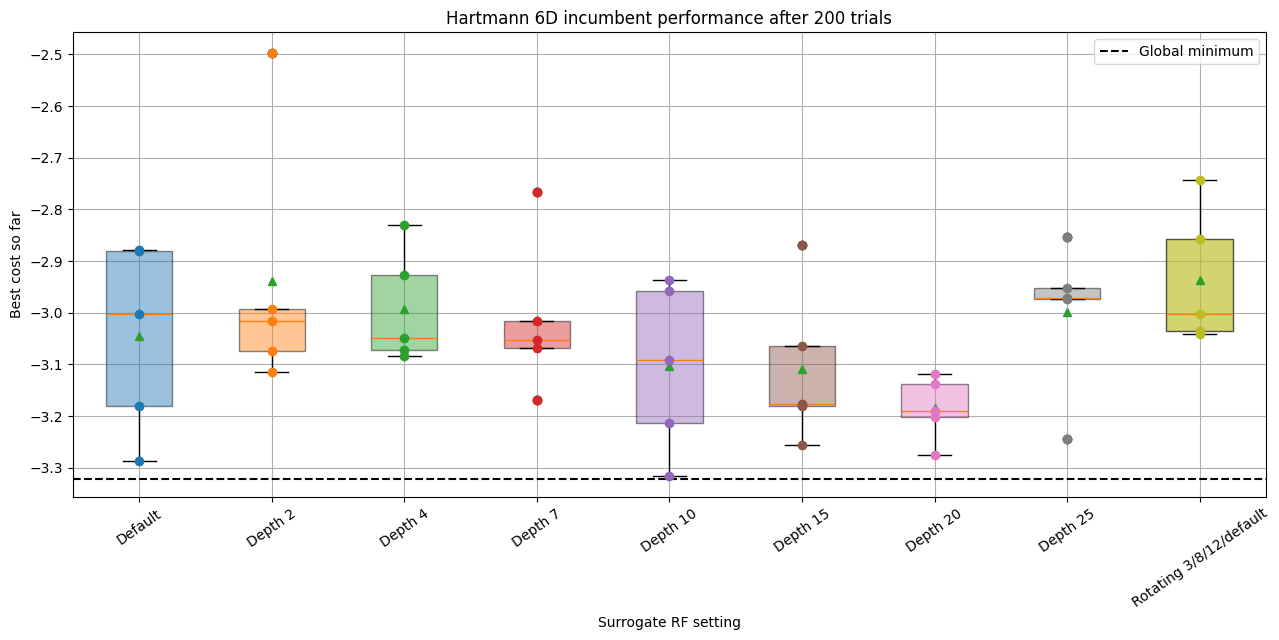

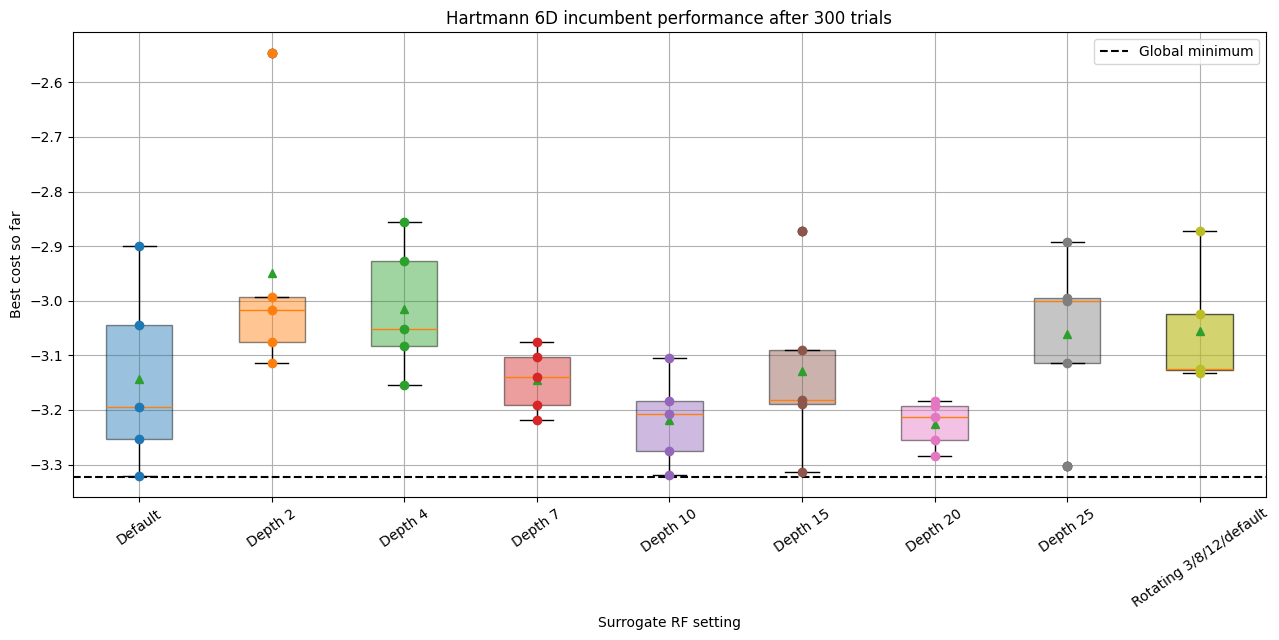

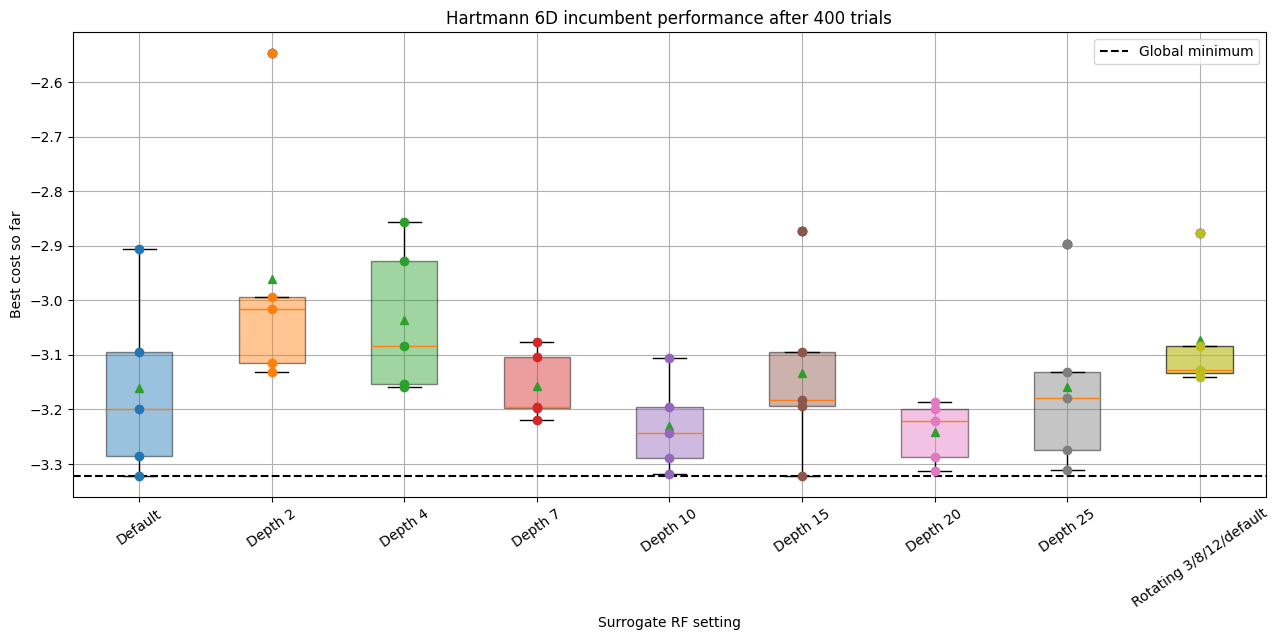

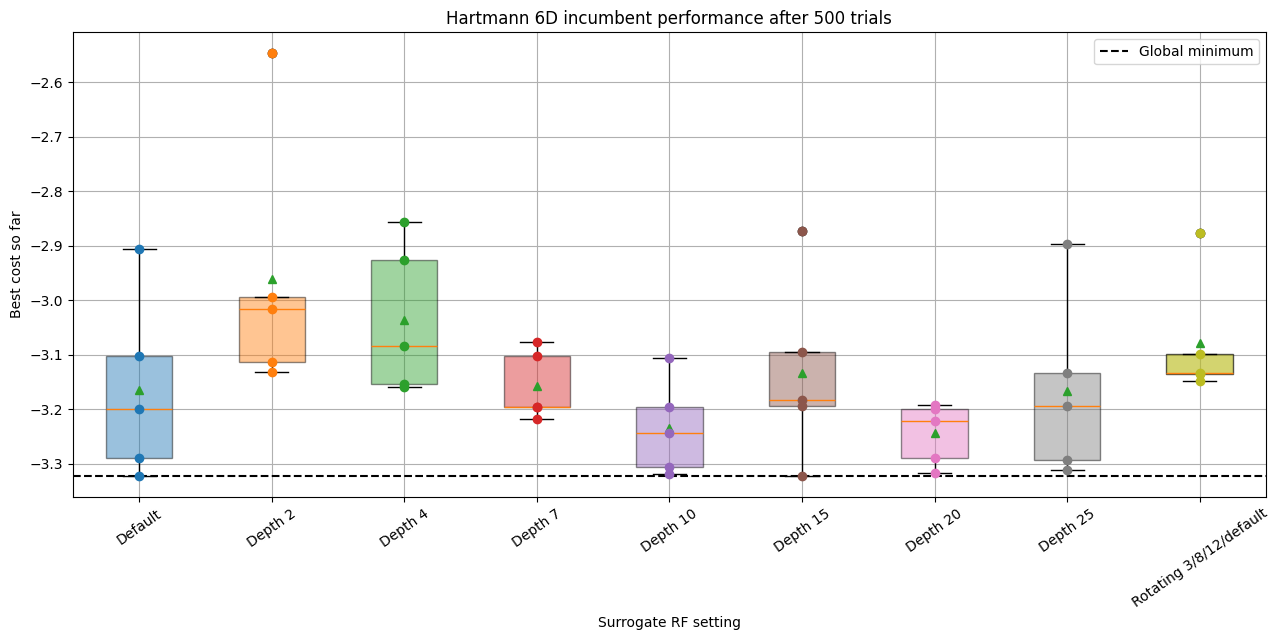

In [14]:
for milestone in [100, 200, 300, 400, 500]:
    milestone_costs = [incumbent_costs[label][:, milestone - 1] for label in labels]

    fig, ax = plt.subplots(figsize=(13, 6.5))
    boxplot = ax.boxplot(
        milestone_costs, tick_labels=labels, showmeans=True, patch_artist=True
    )
    for patch, label in zip(boxplot["boxes"], labels):
        patch.set_facecolor(colors[label])
        patch.set_alpha(0.65 if label == ROTATING_LABEL else 0.45)
    for position, values in enumerate(milestone_costs, start=1):
        ax.scatter(
            np.full(len(values), position), values,
            color=colors[labels[position - 1]], zorder=3,
        )
    ax.axhline(
        HARTMANN_6D_MINIMUM, color="black", linestyle="--",
        label="Global minimum",
    )
    ax.set_xlabel("Surrogate RF setting")
    ax.set_ylabel("Best cost so far")
    ax.set_title(f"Hartmann 6D incumbent performance after {milestone} trials")
    ax.tick_params(axis="x", rotation=35)
    ax.legend()
    plt.tight_layout()
    plt.show()